# Predicción de Churn — Gimnasio FitLife

Notebook de experimentación para predecir qué socios no renovarán su suscripción,
combinando datos de los módulos de Odoo.

**Target:** `estado == 'Baja'` en el módulo de Contactos.


## 0 · Setup

In [65]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
SEED = 42

## 1 · Carga y construcción del dataset maestro

In [66]:
def load(name):
    return pd.read_csv(
        DATA_DIR / f'{name}.csv', 
        encoding='utf-8-sig', 
        low_memory=False,
    )

contactos     = load('contactos').rename(columns={'id': 'cliente_id'})
crm           = load('crm_leads')
ventas        = load('ventas_servicios')
suscripciones = load('suscripciones')
facturacion   = load('facturacion')
marketing     = load('marketing_automation')
encuestas     = load('encuestas_satisfaccion')
eventos       = load('eventos_participacion')
helpdesk      = load('helpdesk_tickets')
actividad     = load('actividad_deportiva')
engagement    = load('engagement').rename(columns={'participacion_retos': 'participacion_retos_eng'})
centros       = load('centros_deportivos')


df = contactos.copy()

for t in [
    crm, 
    ventas, 
    suscripciones, 
    facturacion,
    marketing, 
    encuestas, 
    eventos, 
    helpdesk,
    actividad, 
    engagement,
]:
    df = df.merge(t, on='cliente_id', how='left')

df = df.merge(
    centros, 
    left_on='centro_id', 
    right_on='id', 
    how='left', 
    suffixes=('', '_centro'),
)

df['churn'] = (df['estado'] == 'Baja').astype(int)
df

,cliente_id,nombre,apellidos,edad,sexo,fecha_nacimiento,codigo_postal,ciudad,distancia_gimnasio_km,fecha_alta,estado,segmento,objetivo_deportivo,centro_id,entrenador_asignado_id,canal_captacion,comercial_asignado,lead_score,fecha_primera_visita,fecha_conversion,num_llamadas,num_reuniones,oferta_aceptada,campana_origen,tiempo_hasta_cierre_dias,plan_contratado,precio_plan,entrenador_personal,nutricionista,spa,...,engagement_score,id,nombre_centro,ciudad_centro,director,fecha_apertura,piscina_centro,spa_centro,parking,sala_crossfit,sala_yoga,sala_funcional,ocupacion_media_pct,ocupacion_hora_punta_pct,aforo_maximo,horario,num_entrenadores,cambio_reciente_director,rotacion_entrenadores_pct,nps_centro,valoracion_media,limpieza_valoracion,incidencias_abiertas_centro,competidor_cercano,distancia_competidor_km,fecha_apertura_competidor,promocion_activa,evento_activo,campana_local,churn
0,1,Jose Manuel,Bou Arévalo,39,Hombre,1986-11-01,48005,Bilbao,5.000,2026-06-08,Activo,Básico,Perder peso,5,29,Referido,Comercial_5,56,2026-05-30,2026-06-08,8,3,Descuento 20%,Verano Active,4,Solo Clases,34.990,True,True,False,...,60,5,FitLife Bilbao,Bilbao,Alba Mar Flor Rivas,2013-01-01,False,True,True,True,True,True,75.100,79.900,450,06:00–23:00,14,False,21.100,29,3.800,3.600,8,Altafit,2.300,2026-02-02,False,False,True,0
1,2,Teodora,Canals Coronado,30,Mujer,1995-09-06,8030,Barcelona,5.400,2026-02-16,Activo,VIP,Perder peso,2,22,Web,Comercial_2,86,2025-12-30,2026-02-16,8,0,Sin matrícula,Campaña Local,28,Premium,64.990,False,False,False,...,78,2,FitLife Barcelona Gràcia,Barcelona,Buenaventura de Bonet,2013-02-13,True,False,True,True,True,True,74.400,82.800,350,06:00–23:00,11,False,13.400,25,4.000,3.800,11,Altafit,1.500,2014-02-03,True,False,True,0
2,3,Mauricio,Cuesta Roca,29,Hombre,1997-03-02,48001,Bilbao,8.100,2026-01-26,Baja,Estándar,Bienestar general,5,18,Redes Sociales,Comercial_7,50,2025-12-05,2026-01-26,4,2,Ninguna,San Valentín Fit,37,Básico,29.990,False,True,False,...,61,5,FitLife Bilbao,Bilbao,Alba Mar Flor Rivas,2013-01-01,False,True,True,True,True,True,75.100,79.900,450,06:00–23:00,14,False,21.100,29,3.800,3.600,8,Altafit,2.300,2026-02-02,False,False,True,1
3,4,María,Bartolomé Plaza,32,Mujer,1994-04-03,8015,Barcelona,6.700,2026-03-30,Activo,Premium,Rehabilitación,2,16,Email Marketing,Comercial_7,77,2026-03-06,2026-03-30,3,3,Pack Familiar,Orgánico,18,Premium,64.990,True,True,False,...,69,2,FitLife Barcelona Gràcia,Barcelona,Buenaventura de Bonet,2013-02-13,True,False,True,True,True,True,74.400,82.800,350,06:00–23:00,11,False,13.400,25,4.000,3.800,11,Altafit,1.500,2014-02-03,True,False,True,0
4,5,Graciano,Solé Ángel,54,Hombre,1971-09-01,46015,Valencia,4.100,2026-03-08,Activo,Básico,Perder peso,3,1,Email Marketing,Comercial_5,37,2026-02-24,2026-03-08,5,3,Precio especial online,Verano Active,11,VIP,99.990,True,False,False,...,35,3,FitLife Valencia Norte,Valencia,Ileana Antón-Andrés,2014-03-31,False,False,True,True,True,True,81.000,83.300,350,06:00–23:00,19,True,21.500,69,3.900,3.300,7,Anytime Fitness,2.100,2024-05-31,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,566,Ani,Ros Escribano,37,Mujer,1988-08-20,46025,Valencia,6.900,2025-11-10,Baja,Básico,Perder peso,3,30,Publicidad exterior,Comercial_7,52,2025-09-17,2025-11-10,1,1,Descuento 20%,Verano Active,34,Solo Clases,34.990,False,False,False,...,24,3,FitLife Valencia Norte,Valencia,Ileana Antón-Andrés,2014-03-31,False,False,True,True,True,True,81.000,83.300,350,06:00–23:00,19,True,21.500,69,3.900,3.300,7,Anytime Fitness,2.100,2024-05-31,True,False,False,1
566,567,Magdalena,Marin Montesinos,48,Mujer,1977-08-23,46010,Valencia,9.900,2026-01-02,Baja,Estándar,Mantenimiento,3,19,Google Ads,Comercial_5,54,2025-11-29,2026-01-02,7,3,Sin matrícula,Campaña Local,30,Solo Clases,34.990,True,Fals

## 3 · Feature Engineering

In [ ]:
def feature_engineering(d):
    d = d.copy()
    TODAY = pd.Timestamp("2026-07-01")

    # Variables de actividad semanal
    d['ratio_visitas_7_30'] = (
        d['visitas_ultimos_7_dias']  /
        (d['visitas_ultimos_30_dias'] + 1)
    )

    # Variables de actividad mensual
    d['ratio_visitas_30_90'] = (
        d['visitas_ultimos_30_dias'] / 
        (d['visitas_ultimos_90_dias'] + 1)
    )

    # Ratio de clases canceladas
    d['ratio_clases_canceladas']= (
        d['clases_canceladas_mes'] /
        (d['clases_reservadas_mes'] + 1)
    )

    # Marketing
    d['tasa_apertura_email'] = (
        d['emails_abiertos'] /
        (d['emails_enviados'] + 1)
    )

    d['tasa_apertura_sms'] = (
        d['sms_abiertos'] /
        (d['sms_enviados'] + 1)
    )

    d['tasa_conv_campanas'] = (
        d['campanas_convertidas'] /
        (d['campanas_recibidas'] + 1)
    )

    # Facturación
    d['ratio_precio_uso'] = (
        d['precio_mensual'] /
        (d['visitas_ultimos_30_dias'] + 1)
    )
    d['total_incidencias_pago']= (
        d['num_pagos_rechazados'] +
        d['retrasos_en_pagos'] +
        d['cuotas_pendientes']
    )

    # Antigüedad en días
    d['fecha_alta_dt'] = pd.to_datetime(d['fecha_alta'], errors='coerce')
    d['antiguedad_dias'] = (pd.Timestamp(TODAY) - d['fecha_alta_dt']).dt.days

    # Encuestas
    d['satisfaccion_media'] = d[
        [
            'valoracion_entrenador',
            'valoracion_instalaciones',
            'valoracion_limpieza',
            'valoracion_clases',
        ]
    ].mean(axis=1)
    d['sin_encuesta'] = d['nps'].isna().astype(int)

    # Helpdesk
    d['incidencia_grave'] = (
        (d['reclamaciones'] > 0) |
        (d['incidencias_abiertas'] > 1)
    ).astype(int)

    # Columnas crudas ya absorbidas en las variables engineered de arriba:
    # se eliminan aquí para no duplicar señal más adelante.
    ABSORBED_BY_ENGINEERING = [
        'emails_enviados', 
        'emails_abiertos',
        'sms_enviados', 
        'sms_abiertos',
        'campanas_recibidas', 
        'campanas_convertidas',
        'valoracion_entrenador', 
        'valoracion_instalaciones',
        'valoracion_limpieza', 
        'valoracion_clases',
        'fecha_alta', 
        'fecha_alta_dt',
    ]
    
    d = d.drop(columns=[c for c in ABSORBED_BY_ENGINEERING if c in d.columns])

    return d

df = feature_engineering(df)
print(f'Features tras ingeniería: {df.shape[1]}')


Features tras ingeniería: 127


In [68]:
from sklearn.compose import make_column_selector

# Columnas que no pueden clasificarse por dtype: identificadores, texto libre,
# fechas en crudo sin uso en el feature engineering, y el target.
EXCLUDE_FEATURES = [
    'cliente_id', 
    'centro_id', 
    'entrenador_asignado_id',
    'codigo_postal', 
    'id',
    'nombre', 
    'apellidos', 
    'ciudad', 
    'comentarios', 
    'nombre_centro',
    'ciudad_centro', 
    'director',
    'fecha_nacimiento', 
    'fecha_primera_visita', 
    'fecha_conversion',
    'fecha_inicio', 
    'fecha_proxima_renovacion', 
    'ultima_subida_precio',
    'ultimo_pago', 
    'ultima_incidencia',
    'fecha_apertura', 
    'fecha_apertura_competidor', 
    'horario',
    'estado',
    'churn',
]

y = df['churn']
X = df.drop(columns=[c for c in EXCLUDE_FEATURES if c in df.columns])

X.head()

,edad,sexo,distancia_gimnasio_km,segmento,objetivo_deportivo,canal_captacion,comercial_asignado,lead_score,num_llamadas,num_reuniones,oferta_aceptada,campana_origen,tiempo_hasta_cierre_dias,plan_contratado,precio_plan,entrenador_personal,nutricionista,spa,piscina,clases_premium,servicios_adicionales,num_compras_adicionales,importe_total_compras,renovacion_automatica,antiguedad_meses,num_renovaciones,num_cancelaciones_anteriores,precio_mensual,dias_hasta_renovacion,metodo_pago,...,sala_crossfit,sala_yoga,sala_funcional,ocupacion_media_pct,ocupacion_hora_punta_pct,aforo_maximo,num_entrenadores,cambio_reciente_director,rotacion_entrenadores_pct,nps_centro,valoracion_media,limpieza_valoracion,incidencias_abiertas_centro,competidor_cercano,distancia_competidor_km,promocion_activa,evento_activo,campana_local,ratio_visitas_7_30,ratio_visitas_30_90,ratio_clases_canceladas,tasa_apertura_email,tasa_apertura_sms,tasa_conv_campanas,ratio_precio_uso,total_incidencias_pago,antiguedad_dias,satisfaccion_media,sin_encuesta,incidencia_grave
0,39,Hombre,5.000,Básico,Perder peso,Referido,Comercial_5,56,8,3,Descuento 20%,Verano Active,4,Solo Clases,34.990,True,True,False,False,False,Ninguno,0,0.000,True,1,0,2,30.080,19,Domiciliación bancaria,...,True,True,True,75.100,79.900,450,14,False,21.100,29,3.800,3.600,8,Altafit,2.300,False,False,True,0.182,0.312,0.000,0.000,0.462,0.000,2.735,6,23,3.600,0,1
1,30,Mujer,5.400,VIP,Perder peso,Web,Comercial_2,86,8,0,Sin matrícula,Campaña Local,28,Premium,64.990,False,False,False,False,False,Ninguno,4,224.230,True,4,3,1,64.830,17,Domiciliación bancaria,...,True,True,True,74.400,82.800,350,11,False,13.400,25,4.000,3.800,11,Altafit,1.500,True,False,True,0.000,0.000,0.000,0.240,0.333,0.100,64.830,0,135,3.675,0,0
2,29,Hombre,8.100,Estándar,Bienestar general,Redes Sociales,Comercial_7,50,4,2,Ninguna,San Valentín Fit,37,Básico,29.990,False,True,False,True,False,Ninguno,1,59.880,True,5,4,0,32.100,19,Domiciliación bancaria,...,True,True,True,75.100,79.900,450,14,False,21.100,29,3.800,3.600,8,Altafit,2.300,False,False,True,0.200,0.404,0.125,0.250,0.333,0.000,1.605,4,156,NaN,1,0
3,32,Mujer,6.700,Premium,Rehabilitación,Email Marketing,Comercial_7,77,3,3,Pack Familiar,Orgánico,18,Premium,64.990,True,True,False,False,False,Toalla,5,393.500,False,3,2,1,66.130,19,Domiciliación bancaria,...,True,True,True,74.400,82.800,350,11,False,13.400,25,4.000,3.800,11,Altafit,1.500,True,False,True,0.500,0.200,0.000,0.226,0.400,0.000,33.065,1,93,3.475,0,0
4,54,Hombre,4.100,Básico,Perder peso,Email Marketing,Comercial_5,37,5,3,Precio especial online,Verano Active,11,VIP,99.990,True,False,False,True,True,Toalla,0,0.000,False,4,3,0,100.390,4,Tarjeta crédito,...,True,True,True,81.000,83.300,350,19,True,21.500,69,3.900,3.300,7,Anytime Fitness,2.100,True,False,False,0.000,0.375,0.000,0.200,0.333,0.000,25.098,4,115,3.550,0,0


## 4 · Entrenamiento de modelos

**Split temporal, no aleatorio.** Igual que en `survival_churn_analysis.ipynb`,
el caso de uso real es siempre hacia adelante: se entrena con el histórico y
se puntúa a los socios activos *ahora*. Un split aleatorio mezclaría socios
antiguos y recientes en train y test por igual — optimista, porque en
producción nunca se conoce de antemano el desenlace de alguien recién
apuntado. En su lugar, se entrena con los socios de alta más antigua y se
evalúa con los de alta más reciente (usando `antiguedad_dias`, ya que
`fecha_alta` se descarta durante el feature engineering): un test más
exigente, porque los socios recientes llevan poco tiempo y han tenido menos
oportunidad de darse de baja.

In [69]:
CORTE_ANTIGUEDAD_DIAS = X['antiguedad_dias'].quantile(0.20)

train_mask = X['antiguedad_dias'] >= CORTE_ANTIGUEDAD_DIAS   # altas antiguas
test_mask  = ~train_mask                                      # altas recientes

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print(f'Corte de antigüedad: {CORTE_ANTIGUEDAD_DIAS:.0f} días')
print(f'Train (altas antiguas): {len(X_train)}  |  Test (altas recientes): {len(X_test)}')
print(f'Churn train: {y_train.mean():.1%}  |  Churn test: {y_test.mean():.1%}')

Corte de antigüedad: 96 días
Train (altas antiguas): 457  |  Test (altas recientes): 113
Churn train: 27.8%  |  Churn test: 15.9%


In [70]:
preprocessor = ColumnTransformer([
    (
        'num', 
        Pipeline(
            [
                ('imp', SimpleImputer(strategy='median')),
                ('scl', StandardScaler()),
            ],
        ), 
        make_column_selector(dtype_include='number'),
        ),
    (
        'cat',
        Pipeline(
            [
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
            ]
        ),
        make_column_selector(dtype_include='object'),
    ),
    (
        'bin',
        Pipeline(
            [
                ('to_num', FunctionTransformer(lambda x: x.astype(int))),
                ('imp', SimpleImputer(strategy='most_frequent')),
            ],
        ),
        make_column_selector(dtype_include='bool'),
    ),
], remainder='drop')
print('Preprocessor listo.')


Preprocessor listo.


In [71]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Desbalanceo (scale_pos_weight): {scale_pos:.2f}')

MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=100,
        class_weight='balanced',
        C=0.1, 
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        max_depth=7, 
        class_weight='balanced',
        min_samples_leaf=5, 
        n_jobs=-1, 
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, 
        max_depth=5, 
        learning_rate=0.05,
        scale_pos_weight=scale_pos, 
        subsample=0.8, 
        colsample_bytree=0.8,
        eval_metric='logloss', 
        verbosity=0, 
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, 
        max_depth=5, 
        learning_rate=0.05,
        scale_pos_weight=scale_pos, 
        subsample=0.8, 
        colsample_bytree=0.8,
        verbose=-1, 
        random_state=42
    ),
}

pipelines = {}
for name, clf in MODELS.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    print(f'  ✓ {name:<25}  AUC-ROC test = {auc:.3f}')


Desbalanceo (scale_pos_weight): 2.60
  ✓ Logistic Regression        AUC-ROC test = 0.543
  ✓ Random Forest              AUC-ROC test = 0.719
  ✓ XGBoost                    AUC-ROC test = 0.572
  ✓ LightGBM                   AUC-ROC test = 0.534


## 6 · Evaluación y comparativa

In [72]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows = []
for name, pipe in pipelines.items():
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    rep     = classification_report(y_test, y_pred, output_dict=True)
    cv_auc  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    rows.append({
        'Modelo':       name,
        'AUC-ROC test': roc_auc_score(y_test, y_proba),
        'AUC-ROC CV μ': cv_auc.mean(),
        'AUC-ROC CV σ': cv_auc.std(),
        'Precision(1)': rep['1']['precision'],
        'Recall(1)':    rep['1']['recall'],
        'F1(1)':        rep['1']['f1-score'],
    })

df_results = pd.DataFrame(rows).set_index('Modelo')
df_results.style.highlight_max(axis=0, color='#d5f5e3').format('{:.3f}')


,AUC-ROC test,AUC-ROC CV μ,AUC-ROC CV σ,Precision(1),Recall(1),F1(1)
Modelo,,,,,,
Logistic Regression,0.543,0.645,0.050,0.231,0.500,0.316
Random Forest,0.719,0.702,0.044,0.286,0.222,0.250
XGBoost,0.572,0.677,0.040,0.083,0.056,0.067
LightGBM,0.534,0.672,0.044,0.167,0.111,0.133


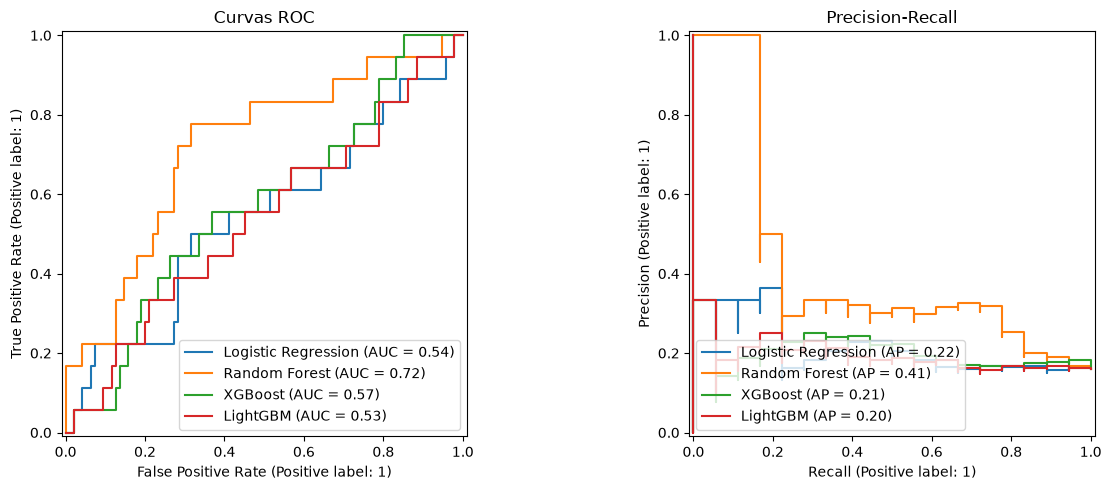

In [73]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[0],)
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[1])

axes[0].set_title('Curvas ROC')
axes[1].set_title('Precision-Recall')
plt.tight_layout()
plt.show()

In [79]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

best_name   = df_results['AUC-ROC test'].idxmax()
best_pipe   = pipelines[best_name]
y_pred_best = best_pipe.predict(X_test)

print(f'Mejor modelo: {best_name}\n')
print(classification_report(y_test, y_pred_best, target_names=['Activo','Baja']))


Mejor modelo: Random Forest

              precision    recall  f1-score   support

      Activo       0.86      0.89      0.88        95
        Baja       0.29      0.22      0.25        18

    accuracy                           0.79       113
   macro avg       0.57      0.56      0.56       113
weighted avg       0.77      0.79      0.78       113



## 7 · Importancia de variables y SHAP

SHAP shape: (100, 102)  |  expected_value: 0.5004


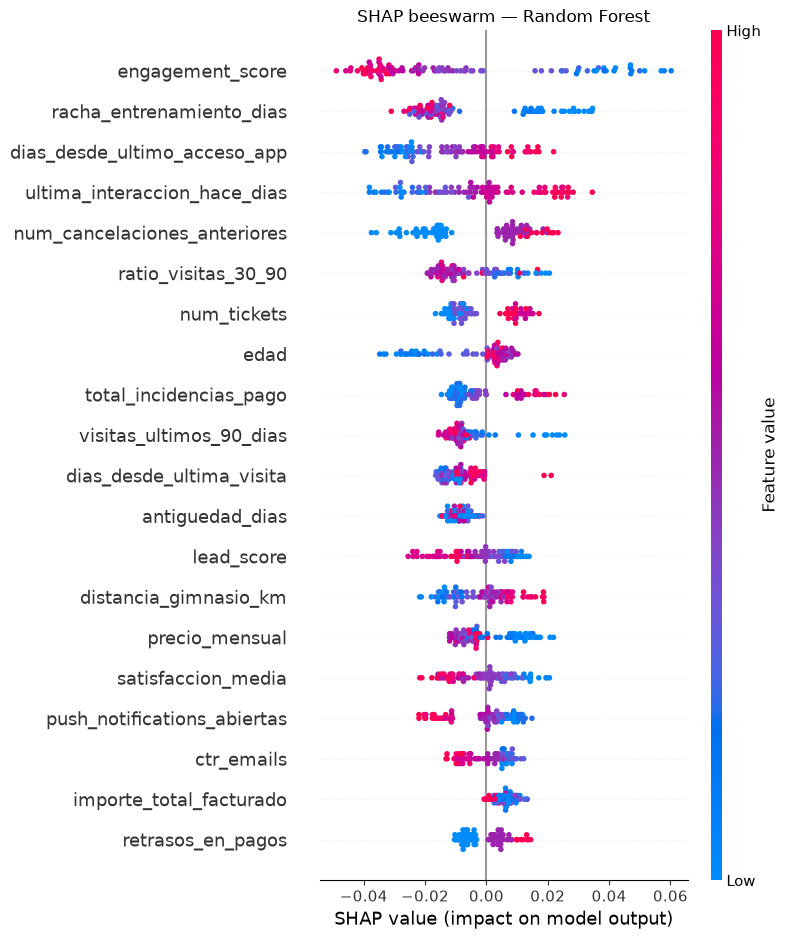

In [75]:
# SHAP sobre el mejor modelo — muestra reducida para eficiencia de memoria
X_test_prep = best_pipe.named_steps['prep'].transform(X_test)
clf_best    = best_pipe.named_steps['clf']

N_SHAP = min(100, len(X_test_prep))
rng = np.random.default_rng(SEED)
idx_sample = rng.choice(len(X_test_prep), size=N_SHAP, replace=False)
X_shap = X_test_prep[idx_sample]

explainer   = shap.TreeExplainer(clf_best)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    sv = shap_values[1]            # lista [clase0, clase1]
elif np.array(shap_values).ndim == 3:
    sv = np.array(shap_values)[:, :, 1]  # 3D (samples, feats, classes)
else:
    sv = shap_values

ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)) and np.atleast_1d(ev).size > 1:
    ev = float(np.atleast_1d(ev)[1])
else:
    ev = float(ev)

print(f'SHAP shape: {sv.shape}  |  expected_value: {ev:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
feature_names = best_pipe.named_steps['prep'].transformers_[0][2] + \
                best_pipe.named_steps['prep'].transformers_[1][2] + \
                best_pipe.named_steps['prep'].transformers_[2][2]
shap.summary_plot(sv, X_shap, feature_names=feature_names, max_display=20, show=False)
plt.title(f'SHAP beeswarm — {best_name}')
plt.tight_layout()
plt.show()

## 8 · Scoring del portfolio de clientes activos

In [76]:
activos = df[df['estado'] == 'Activo'].copy()
activos['churn_proba'] = best_pipe.predict_proba(activos[X.columns])[:, 1]
activos['nivel_riesgo'] = pd.cut(
    activos['churn_proba'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Bajo', 'Medio', 'Alto'],
)

print(f'Clientes activos scorados: {len(activos)}')
print('\nDistribución de riesgo:')
print(activos['nivel_riesgo'].value_counts())


Clientes activos scorados: 425

Distribución de riesgo:
nivel_riesgo
Bajo     225
Medio    181
Alto      19
Name: count, dtype: int64


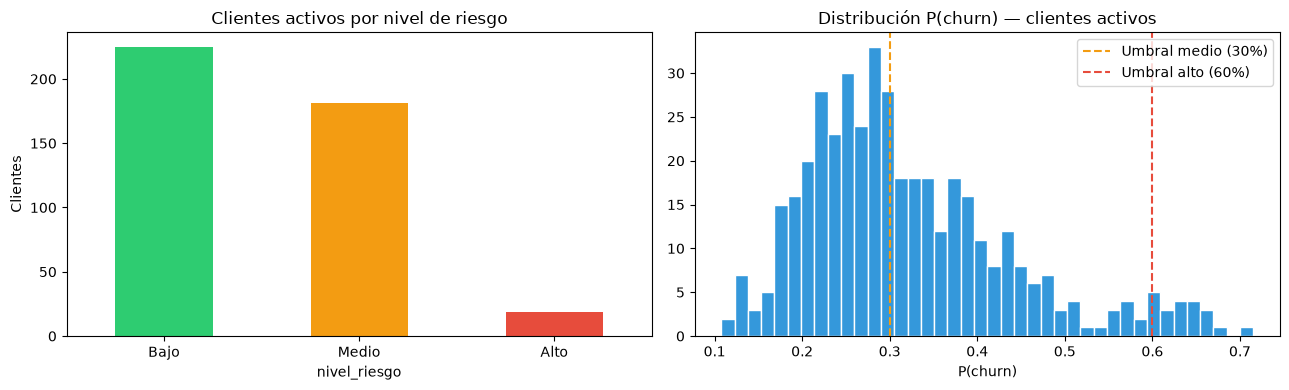

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

activos['nivel_riesgo'].value_counts().reindex(['Bajo','Medio','Alto']).plot.bar(
    ax=axes[0], color=['#2ecc71','#f39c12','#e74c3c'], rot=0
)
axes[0].set_title('Clientes activos por nivel de riesgo')
axes[0].set_ylabel('Clientes')

axes[1].hist(activos['churn_proba'], bins=40, color='#3498db', edgecolor='white')
axes[1].axvline(0.30, color='#f39c12', linestyle='--', label='Umbral medio (30%)')
axes[1].axvline(0.60, color='#e74c3c', linestyle='--', label='Umbral alto (60%)')
axes[1].set_title('Distribución P(churn) — clientes activos')
axes[1].set_xlabel('P(churn)')
axes[1].legend()

plt.tight_layout()
plt.show()


# Conclusiones

## Descubrimientos sobre el comportamiento del cliente

**1. El churn es desenganche progresivo, no sensibilidad al precio.**
Las variables con más peso en el modelo son casi todas de actividad/comportamiento
(`engagement_score`, días sin abrir la app, visitas últimos 90 días, racha de
entrenamiento), no el precio. Comparando medias Activo vs. Baja: `engagement_score`
65.1 → 45.6, días sin abrir la app 29.4 → 56.4, días desde la última visita 23.7 → 48.1,
NPS 5.0 → 3.8. El cliente se apaga durante semanas antes de darse de baja — hay ventana
real para intervenir antes de que decida cancelar.

**2. La renovación automática es el mayor seguro contra el churn.**
Sin renovación automática: 34.1% de baja. Con ella: 23.0%. Palanca barata y accionable
desde el onboarding.

**3. La tendencia de asistencia ya avisa antes de tiempo.**
`tendencia_asistencia = Decreciente` → 29.7% de baja, vs. 20.7% en "Estable". Señal de
alerta temprana que no necesita modelo, solo vigilancia operativa.

**4. No todos los canales de captación traen clientes igual de fieles.**
Referido: 14.9% de baja. Influencer: 35.6%. Web / Publicidad exterior: ~32%. El marketing
de referidos no solo es más barato, también trae clientes más comprometidos.

**5. Hallazgo contraintuitivo a investigar más:** el segmento VIP (30.3%) y el plan Básico
(36.6%) tienen más churn que Premium (19.4%). Podría reflejar expectativas no cubiertas en
VIP, o un perfil de cliente menos comprometido en Básico — no concluyente sin cruzarlo con
satisfacción por segmento.

**6. El patrón de riesgo estacional (adulto, alta 6-12 meses, inactivo ~3 meses antes del
verano) es real y detectable:** ~61% de churn dentro del patrón vs. ~20% fuera de él, y el
modelo lo usa como señal fuerte de riesgo al puntuar clientes activos.

## Próximos pasos

- [ ] Optimización de hiperparámetros con **Optuna**
- [ ] Tendencia temporal de accesos (ventana deslizante 7/14/30/60 días)
- [ ] Calibración de probabilidades (Platt scaling / isotonic regression)
- [ ] Umbral óptimo según coste de intervención vs. CLV del cliente
- [ ] Integrar scoring en `customer_health` de Odoo vía **XML-RPC / REST API**
- [ ] A/B test de acciones para medir impacto real sobre retención
- [ ] Acción específica para el patrón pre-verano: SMS ofreciendo pausar la suscripción 1 mes
